In [1]:
import sys
import importlib

# Ensure utils are in path
from pathlib import Path
NOTEBOOK_DIR = Path.cwd()
UTILS_DIR = next(
    (candidate / "utils" for candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents] if (candidate / "utils").is_dir()),
    None,
)
if UTILS_DIR and str(UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(UTILS_DIR))

# Try to reload the modules
import two_stage_common
import regressor_tuning_common

importlib.reload(two_stage_common)
importlib.reload(regressor_tuning_common)

print("Modules reloaded.")
print(f"mlflow in two_stage_common: {two_stage_common.mlflow}")
print(f"mlflow in regressor_tuning_common: {regressor_tuning_common.mlflow}")

Modules reloaded.
mlflow in two_stage_common: <module 'mlflow' from '/home/sophia/www/cesar/6/projetos/Projetos-6-Saltim/.venv/lib/python3.12/site-packages/mlflow/__init__.py'>
mlflow in regressor_tuning_common: <module 'mlflow' from '/home/sophia/www/cesar/6/projetos/Projetos-6-Saltim/.venv/lib/python3.12/site-packages/mlflow/__init__.py'>


In [2]:

# Investigating the Index/Columns dtype
from regressor_tuning_common import prepare_threshold_regression_data
import pandas as pd

data = prepare_threshold_regression_data(sample_frac=0.01)
X = data["X_search"]

print(f"Columns Index type: {type(X.columns)}")
print(f"Columns Index dtype: {X.columns.dtype}")
print(f"First 5 column names: {X.columns[:5].tolist()}")

# Check if any part of the index or metadata uses StringDtype
try:
    from pandas.api.types import is_string_dtype
    print(f"Is Columns Index string dtype? {is_string_dtype(X.columns)}")
except:
    pass

# Try to force columns to object
X.columns = X.columns.astype(object)
print(f"After conversion - Columns Index dtype: {X.columns.dtype}")

Columns Index type: <class 'pandas.core.indexes.base.Index'>
Columns Index dtype: object
First 5 column names: ['unidade', 'categoria_id', 'is_compravel', 'is_produzido_internamente', 'categoria']
Is Columns Index string dtype? True
After conversion - Columns Index dtype: object


# Tuning - Random Forest Regressor para limiar de reposicao

Este notebook desenvolve o sucessor do artefato historico `03_tree_ensembles_random_forest_regressor_threshold_model.pkl`, mas sem salvar `.pkl` localmente. O modelo, metricas, predicoes, parametros e graficos sao registrados diretamente no MLflow.


## Estrategia

Usamos `TimeSeriesSplit`, uma validacao cruzada temporal. Ela preserva a ordem passado -> futuro e evita vazamento temporal, que ocorreria com K-Fold aleatorio. O conjunto `test` fica isolado para avaliacao final do campeao.

O tuning usa `RandomizedSearchCV` com uma configuracao leve, porque o grid completo seria caro para florestas com varias combinacoes de profundidade, folhas e numero de arvores. A busca avalia poucos candidatos e apenas os perfis de peso principais para poupar CPU.


In [3]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
UTILS_DIR = next(
    (candidate / "utils" for candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents] if (candidate / "utils").is_dir()),
    None,
)
if UTILS_DIR is None:
    raise RuntimeError("Nao encontrei ml/notebooks/utils. Execute o notebook dentro do repositorio Saltim.")
sys.path.insert(0, str(UTILS_DIR))

import pandas as pd

from regressor_tuning_common import (
    RegressorTuningConfig,
    WEIGHT_PROFILE_DESCRIPTIONS,
    run_regressor_tuning,
)

from sklearn.ensemble import RandomForestRegressor


In [4]:
RF_PARAM_DISTRIBUTIONS = {
    "model__n_estimators": [80, 120, 180],
    "model__max_depth": [6, 10, 14],
    "model__min_samples_split": [5, 10, 20],
    "model__min_samples_leaf": [2, 4, 8],
    "model__max_features": ["sqrt", 0.5, 0.8],
    "model__bootstrap": [True],
}

def rf_model_factory() -> RandomForestRegressor:
    return RandomForestRegressor(random_state=42, n_jobs=2)

def rf_baseline_factory() -> RandomForestRegressor:
    return RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=2)

config = RegressorTuningConfig(
    notebook_id="05_random_forest_regressor_threshold_tuning",
    family="Arvores",
    model_name="Random Forest Regressor",
    model_factory=rf_model_factory,
    baseline_factory=rf_baseline_factory,
    param_distributions=RF_PARAM_DISTRIBUTIONS,
    n_iter=6,
    cv_splits=3,
    random_state=42,
    n_jobs=1,
    use_full_dataset=True,
    weight_profiles=("uniform", "alert_focus"),
)

search_space = pd.DataFrame(
    [{"parametro": key, "valores": values} for key, values in RF_PARAM_DISTRIBUTIONS.items()]
)
weight_profiles = pd.DataFrame(
    [
        {"perfil": key, "descricao": WEIGHT_PROFILE_DESCRIPTIONS[key]}
        for key in config.weight_profiles
    ]
)

display(search_space)
display(weight_profiles)


,parametro,valores
0,model__n_estimators,"[80, 120, 180]"
1,model__max_depth,"[6, 10, 14]"
2,model__min_samples_split,"[5, 10, 20]"
3,model__min_samples_leaf,"[2, 4, 8]"
4,model__max_features,"[sqrt, 0.5, 0.8]"
5,model__bootstrap,[True]


,perfil,descricao
0,uniform,Peso 1 para todas as amostras; usado como cont...
1,alert_focus,Aumenta peso de observacoes em Alerta de compr...


## Execucao do tuning

A celula abaixo executa baseline, buscas randomicas por perfil de peso, registro dos candidatos no MLflow, treino final do campeao e diagnosticos de ajuste. A configuracao foi reduzida para poupar CPU: poucos candidatos, 3 folds, dois perfis de peso e paralelismo limitado.


2026/06/01 19:37:37 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/06/01 19:37:41 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/sophia/www/cesar/6/projetos/Projetos-6-Saltim/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/01 19:39:29

🏃 View run Random Forest Regressor baseline at: http://localhost:5000/#/experiments/17/runs/2a1bca60072845ee9d53f5f0eae3e013
🧪 View experiment at: http://localhost:5000/#/experiments/17


2026/06/01 20:02:05 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/sophia/www/cesar/6/projetos/Projetos-6-Saltim/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Fitting 3 folds for each of 6 candidates, totalling 18 fits


2026/06/01 20:30:46 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/sophia/www/cesar/6/projetos/Projetos-6-Saltim/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/01 20:30:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format require

...

🏃 View run Random Forest Regressor candidate alert_focus #2 at: http://localhost:5000/#/experiments/17/runs/5065cdea46344be388ed3cc02b4d0840
🧪 View experiment at: http://localhost:5000/#/experiments/17


2026/06/01 20:54:32 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


🏃 View run Random Forest Regressor candidate alert_focus #0 at: http://localhost:5000/#/experiments/17/runs/70875dd534154fd98a7b7b79ab129491
🧪 View experiment at: http://localhost:5000/#/experiments/17
🏃 View run Random Forest Regressor candidate alert_focus #1 at: http://localhost:5000/#/experiments/17/runs/61cdc43bce974110be26fdd16df264a1
🧪 View experiment at: http://localhost:5000/#/experiments/17
🏃 View run Random Forest Regressor random search - alert_focus at: http://localhost:5000/#/experiments/17/runs/a3408159b5f14317b85f8130ce6f023b
🧪 View experiment at: http://localhost:5000/#/experiments/17


2026/06/01 20:54:46 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/sophia/www/cesar/6/projetos/Projetos-6-Saltim/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/01 20:59:47 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/sophi

🏃 View run Random Forest Regressor champion at: http://localhost:5000/#/experiments/17/runs/018402e73c3b4146afe839d2907b0633
🧪 View experiment at: http://localhost:5000/#/experiments/17
🏃 View run Random Forest Regressor tuning parent at: http://localhost:5000/#/experiments/17/runs/05ecbf26318e4ea7935c62ba61b121bf
🧪 View experiment at: http://localhost:5000/#/experiments/17


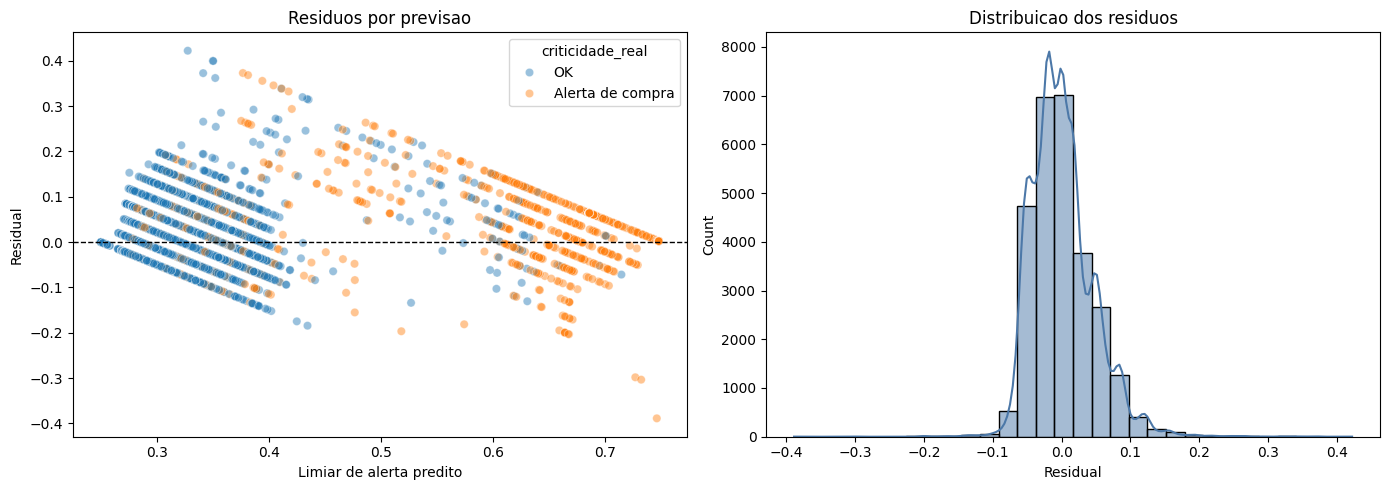

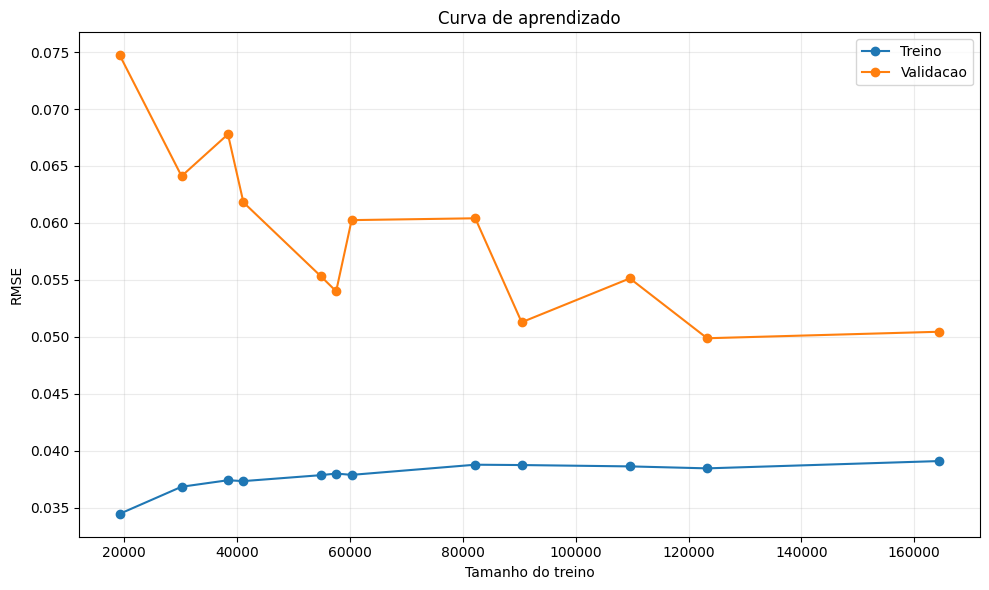

In [5]:
results = run_regressor_tuning(config)

## Resultados quantitativos

As tabelas abaixo mostram baseline, melhores candidatos, variancia entre folds e metricas finais no teste.


In [6]:
display(results["baseline_summary"])
display(results["candidate_results"].head(15))
display(results["best_fold_metrics"])
display(results["final_metrics"].T)
print("Melhor perfil de peso:", results["best_weight_profile"])
print("Melhores hiperparametros:", results["best_params"])
print("Diagnostico:", results["fit_diagnosis"])


,baseline_cv_train_rmse_mean,baseline_cv_train_rmse_std,baseline_cv_validation_rmse_mean,baseline_cv_validation_rmse_std,baseline_cv_validation_rmse_var,baseline_cv_validation_mae_mean,baseline_cv_validation_r2_mean,baseline_test_rmse,baseline_test_mae,baseline_test_r2
0,0.012468,0.000142,0.056099,0.003284,0.000011,0.038555,0.705558,0.046108,0.034283,0.795245


,candidate_index,weight_profile,params_json,mean_train_rmse,std_train_rmse,mean_validation_rmse,std_validation_rmse,mean_train_mae,mean_validation_mae,mean_train_r2,mean_validation_r2,rank_validation_rmse,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,bootstrap
0,4,uniform,"{""model__bootstrap"": true, ""model__max_depth"":...",0.038526,0.000511,0.053637,0.002257,0.029268,0.037847,0.855177,0.730599,1,120,10,8,0.8,14,True
1,3,uniform,"{""model__bootstrap"": true, ""model__max_depth"":...",0.038428,0.000578,0.054012,0.002677,0.029270,0.037801,0.855920,0.726977,2,120,20,4,0.8,14,True
2,5,uniform,"{""model__bootstrap"": true, ""model__max_depth"":...",0.039087,0.001100,0.054914,0.003932,0.030266,0.039213,0.850950,0.716829,3,120,10,4,sqrt,14,True
3,2,uniform,"{""model__bootstrap"": true, ""model__max_depth"":...",0.043763,0.000514,0.054916,0.002371,0.033583,0.038792,0.813121,0.717841,4,180,20,4,0.8,10,True
6,5,alert_focus,"{""model__bootstrap"": true, ""model__max_depth"":...",0.039178,0.001225,0.055351,0.004303,0.030397,0.039610,0.850236,0.711816,1,120,10,4,sqrt,14,True
7,4,alert_focus,"{""model__bootstrap"": true, ""model__max_depth"":...",0.035853,0.001400,0.055815,0.001584,0.027060,0.038113,0.874560,0.708593,2,120,10,8,0.8,14,True
8,3,alert_focus,"{""model__bootstrap"": true, ""model__max_depth"":...",0.035925,0.001340,0.055913,0.001897,0.027198,0.038107,0.874054,0.707613,3,120,20,4,0.8,14,True
9,2,alert_focus,"{""model__bootstrap"": true, ""model__max_depth"":...",0.042098,0.001240,0.056397,0.001876,0.032489,0.039132,0.827079,0.702615,4,180,20,4,0.8,10,True
10,0,alert_focus,"{""model__bootstrap"": true, ""model__max_depth"":...",0.057072,0.000739,0.061755,0.003096,0.044160,0.046384,0.682139,0.642365,5,80,20,8,sqrt,6,True
11,1,alert_focus,"{""model__bootstrap"": true, ""model__max_depth"":...",0.057014,0.000854,0.061868,0.002941,0.044172,0.046469,0.682818,0.641165,6,80,20,2,sqrt,6,True


,fold,weight_profile,train_rmse,validation_rmse,train_mae,validation_mae,train_r2,validation_r2
0,1,uniform,0.037856,0.055333,0.028525,0.039437,0.856050,0.705611
1,2,uniform,0.038627,0.055132,0.029439,0.038332,0.853442,0.735350
2,3,uniform,0.039094,0.050447,0.029839,0.035771,0.856040,0.750834


,0
notebook,05_random_forest_regressor_threshold_tuning
family,Arvores
stage,threshold_regression
model,Random Forest Regressor
accuracy,0.998921
balanced_accuracy,0.997761
f1_macro,0.997949
precision_macro,0.998136
recall_macro,0.997761
taxa_ok,0.844281


Melhor perfil de peso: uniform
Melhores hiperparametros: {'model__n_estimators': 120, 'model__min_samples_split': 10, 'model__min_samples_leaf': 8, 'model__max_features': 0.8, 'model__max_depth': 14, 'model__bootstrap': True}
Diagnostico: {'fit_status': 'adequate', 'fit_explanation': 'Nao ha sinal forte de sobreajuste/subajuste nos criterios adotados.', 'train_validation_rmse_gap': 0.014014403692054235, 'train_validation_rmse_gap_ratio': 0.3536929061670827, 'validation_rmse_std': 0.0022572883513544044}


## Visualizacoes de ajuste

A curva de aprendizado ajuda a identificar overfitting ou underfitting. A analise de residuos mostra vieses e dispersao dos erros no limiar previsto.


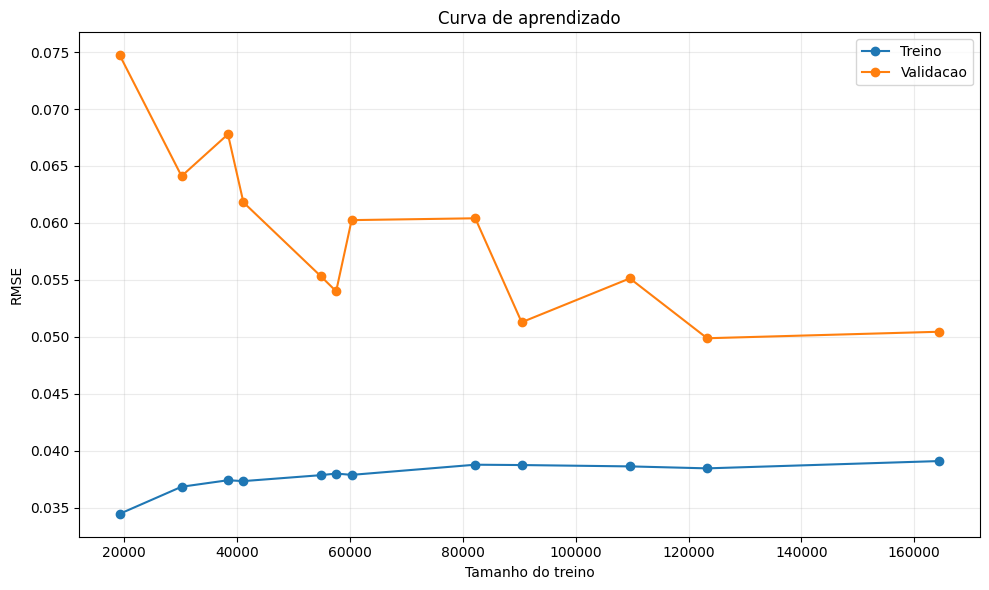

In [7]:
results["figures"]["learning_curve"]


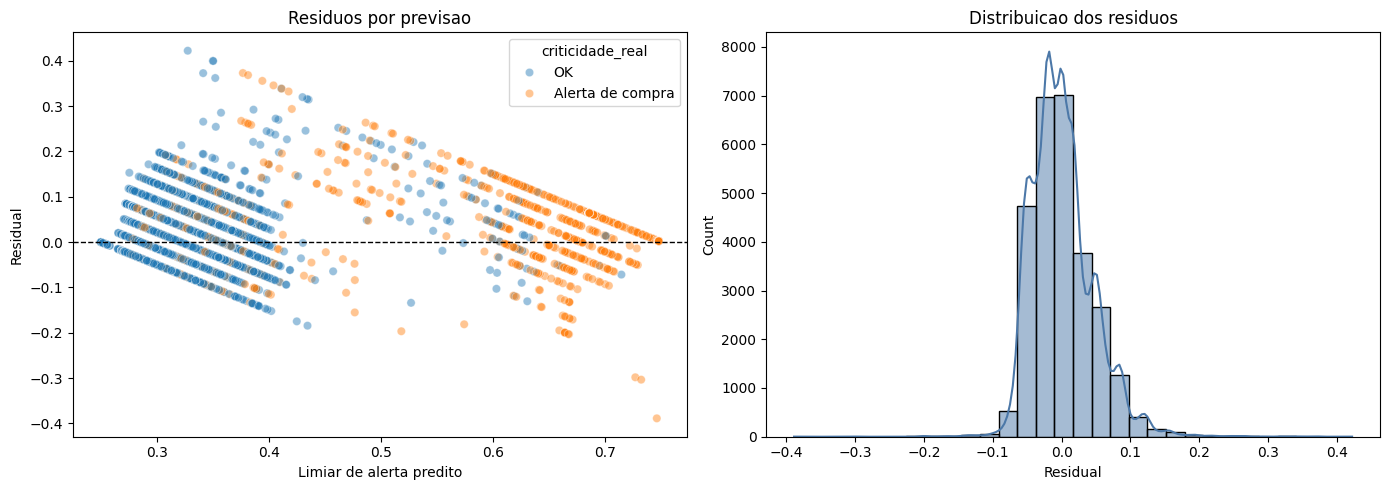

In [8]:
results["figures"]["residual_analysis"]


## MLflow

No MLflow, procure pelos runs do experimento `notebooks/02_modelos_finais/05_random_forest_regressor_threshold_tuning/threshold_regression`. Os runs de candidatos guardam combinacoes de parametros e pesos; o run `champion` guarda o modelo registrado, predicoes, metricas finais e graficos.
